In [1]:
import json
import os
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from google import genai
import time

In [ ]:
MESSAGES_PATH = ""
CUTOFF_DATE   = datetime(2024, 11, 1, tzinfo=timezone.utc)

In [ ]:
client = genai.Client(api_key="")
MODEL_ID = "gemini-2.5-flash-lite"

BATCH_SIZE = 80

In [10]:
def load_json_records(path: str) -> list[dict]:
    p = Path(path)
    files = sorted(p.glob("**/*.json")) if p.is_dir() else [p]
    if not files:
        raise FileNotFoundError(f"No .json files found at: {path}")

    records = []
    for fp in files:
        raw = fp.read_text(encoding="utf-8").strip()
        try:
            data = json.loads(raw)
            if isinstance(data, list):
                records.extend(data)
            elif isinstance(data, dict):
                records.append(data)
        except json.JSONDecodeError:
            for line in raw.splitlines():
                line = line.strip().rstrip(",")
                if line:
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    return records

def parse_date(value) -> datetime | None:
    if isinstance(value, dict) and "$date" in value:
        value = value["$date"]
    if isinstance(value, str):
        try:
            return datetime.fromisoformat(value.replace("Z", "+00:00"))
        except ValueError:
            return None
    return None

def freq_table(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.value_counts().reset_index()
    counts.columns = [label, "count"]
    counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(1)
    return counts



In [5]:
raw = load_json_records(MESSAGES_PATH)

flat_rows = []
for doc in raw:
    doc_date = parse_date(doc.get("createdAt"))
    if doc_date is None or doc_date < CUTOFF_DATE:
        continue
    doc_id = (doc.get("_id") or {}).get("$oid", "")
    for msg in doc.get("messages", []):
        q = (msg.get("question") or "").strip()
        a = (msg.get("answer")   or "").strip()
        if not q:
            continue
        msg_date = parse_date(msg.get("createdAt")) or doc_date
        flat_rows.append({
            "doc_id":   doc_id,
            "msg_date": msg_date,
            "month":    msg_date.strftime("%Y-%m"),
            "question": q,
            "answer":   a,
        })

df = pd.DataFrame(flat_rows)

In [6]:
CLASSIFICATION_PROMPT = """\
You are a data analyst classifying student/teacher chat messages from an \
Indian K-12 educational platform.

For EACH numbered message below, return a JSON object with exactly these keys:
  "intent"        – one of: explanation_request | translation_request |
                    exam_prep | homework_help | definition | example_request |
                    other
  "subject"       – one of: mathematics | science | physics | chemistry |
                    biology | history | geography | english | hindi |
                    other_language | general | other
  "non_english"   – true if the question is written in or explicitly asks for
                    a non-English language (Hindi, Marathi, Tamil, etc.), else false
  "language"      – detected language of the question text (e.g. "English",
                    "Hindi", "Marathi", "Telugu" …)
  "grade_mention" – grade/class number mentioned (integer), or null

Return ONLY a JSON array — one object per message, in the same order.
No markdown fences, no extra commentary.

Messages:
"""

In [7]:
def classify_batch(questions: list[str], retries=5):
    numbered = "\n".join(f"{i+1}. {q[:300]}" for i, q in enumerate(questions))
    prompt = CLASSIFICATION_PROMPT + numbered
    fallback = [{"intent": "error", "subject": "error", 
                 "non_english": False, "language": "unknown", 
                 "grade_mention": None}] * len(questions)
    
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model=MODEL_ID,
                contents=prompt,
                config={"temperature": 0.1, "response_mime_type": "application/json"}
            )
            
            result = response.parsed
            if result is None:
                raw_text = response.text.strip()
                if raw_text.startswith("```"):
                    raw_text = raw_text.split("```")[1]
                    if raw_text.startswith("json"):
                        raw_text = raw_text[4:]
                result = json.loads(raw_text)
            
            if not isinstance(result, list):
                raise ValueError(f"Expected list, got {type(result)}")
            
            if len(result) != len(questions):
                print(f"\n[Warning] Got {len(result)} labels for {len(questions)} questions. Adjusting.")
                if len(result) > len(questions):
                    result = result[:len(questions)]
                else:
                    result.extend(fallback[:len(questions) - len(result)])
            
            return result

        except Exception as e:
            if "429" in str(e) or "503" in str(e):
                wait = (2 ** attempt) * 15  
                print(f"\n[Retry {attempt+1}] Sleeping {wait}s... ({type(e).__name__})")
                time.sleep(wait)
            else:
                print(f"\n[Error on attempt {attempt+1}] {type(e).__name__}: {e}")
                time.sleep(2)
    
    print(f"\n[Failed] All {retries} attempts exhausted. Returning fallback labels.")
    return fallback

In [8]:
all_labels: list[dict] = []
questions  = df["question"].tolist()
total      = len(questions)

for start in range(0, total, BATCH_SIZE):
    batch = questions[start : start + BATCH_SIZE]
    labels = classify_batch(batch)
    all_labels.extend(labels)
    print(f"  {min(start + BATCH_SIZE, total):,} / {total:,}", end="\r")
    time.sleep(15)

labels_df = pd.DataFrame(all_labels)
df = pd.concat([df.reset_index(drop=True), labels_df], axis=1)

  1,251 / 1,251

In [9]:
df.to_csv("classified_messages.csv", index=False)

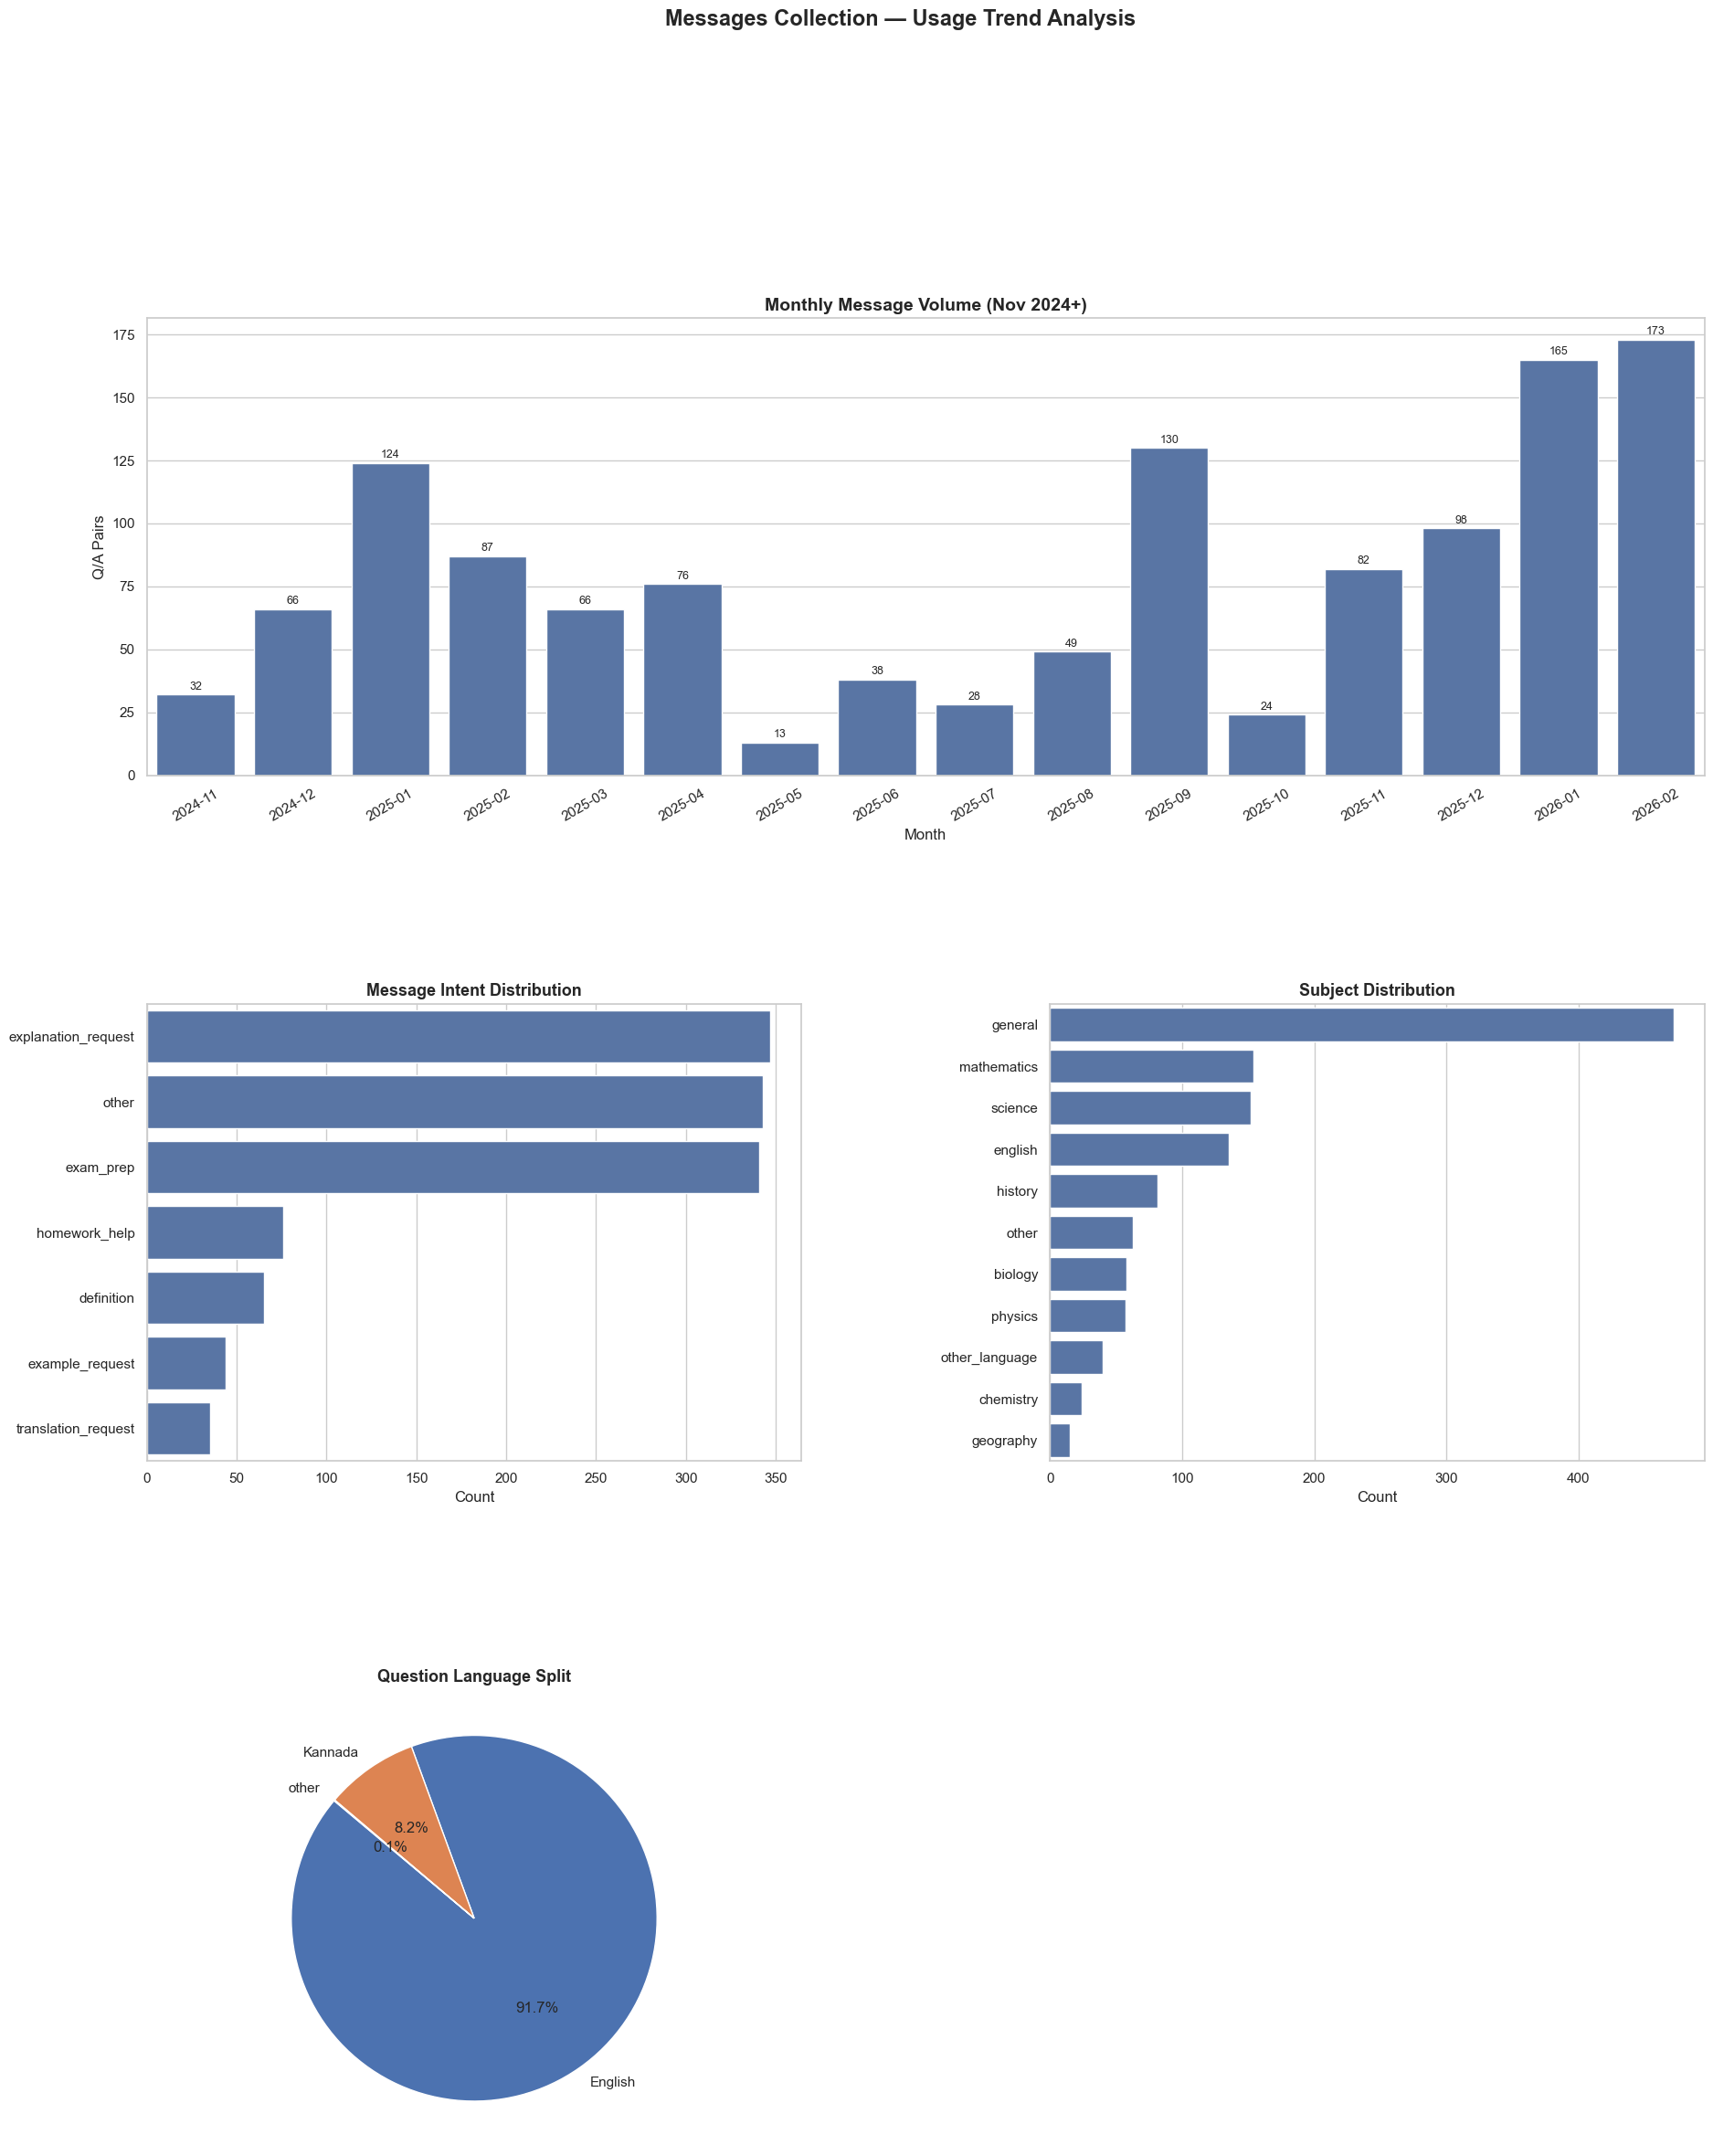

In [ ]:
grade_df = df[df["grade_mention"].notna()].copy()
grade_df["grade_mention"] = grade_df["grade_mention"].astype(int)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(22, 26))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :])
monthly = df.groupby("month").size().reset_index(name="count")
sns.barplot(data=monthly, x="month", y="count", ax=ax1)
ax1.set_title("Monthly Message Volume (Nov 2024+)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Q/A Pairs")
ax1.tick_params(axis="x", rotation=30)
for bar in ax1.patches:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + ax1.get_ylim()[1] * 0.005,
             f"{int(h):,}", ha="center", va="bottom", fontsize=9)


ax2 = fig.add_subplot(gs[1, 0])
intent_data = freq_table(df["intent"], "intent")
sns.barplot(data=intent_data, y="intent", x="count", ax=ax2)
ax2.set_title("Message Intent Distribution", fontsize=13, fontweight="bold")
ax2.set_xlabel("Count")
ax2.set_ylabel("")


ax3 = fig.add_subplot(gs[1, 1])
subject_data = freq_table(df["subject"], "subject")
sns.barplot(data=subject_data, y="subject", x="count", ax=ax3)
ax3.set_title("Subject Distribution", fontsize=13, fontweight="bold")
ax3.set_xlabel("Count")
ax3.set_ylabel("")


ax4 = fig.add_subplot(gs[2, 0])
lang_counts = df["language"].value_counts().head(8)
ax4.pie(lang_counts, labels=lang_counts.index, autopct="%1.1f%%", startangle=140)
ax4.set_title("Question Language Split", fontsize=13, fontweight="bold")


plt.suptitle("Messages Collection — Usage Trend Analysis", fontsize=17,
             fontweight="bold", y=1.01)
plt.show()

In [11]:
TOPIC_PROMPT = """\
You are analyzing chat messages from an Indian K-12 educational platform.
For EACH numbered message below, return a JSON object with exactly these keys:
  "topic"     – a short 2-5 word label describing what the message is about
                (e.g. "study tips", "exam schedule", "teacher greeting",
                "platform navigation", "motivational request", "off-topic chat")
  "category"  – one of: platform_usage | student_support | general_knowledge |
                off_topic | administrative | greeting_or_smalltalk | other
Return ONLY a JSON array — one object per message, in the same order.
No markdown fences, no extra commentary.
Messages:
"""

In [12]:
def topic_batch(questions: list[str], retries=3):
    numbered = "\n".join(f"{i+1}. {q[:300]}" for i, q in enumerate(questions))
    prompt = TOPIC_PROMPT + numbered
    fallback = [{"topic": "unknown", "category": "other"}] * len(questions)

    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model=MODEL_ID,
                contents=prompt,
                config={"temperature": 0.1, "response_mime_type": "application/json"}
            )
            result = response.parsed
            if result is None:
                raw_text = response.text.strip()
                if raw_text.startswith("```"):
                    raw_text = raw_text.split("```")[1]
                    if raw_text.startswith("json"):
                        raw_text = raw_text[4:]
                result = json.loads(raw_text)

            if not isinstance(result, list):
                raise ValueError(f"Expected list, got {type(result)}")
            if len(result) != len(questions):
                result.extend(fallback[:len(questions) - len(result)])

            return result

        except Exception as e:
            if "429" in str(e):
                print(f"\n[Quota Hit] Sleeping 60s (Attempt {attempt+1}/{retries})...")
                time.sleep(60)
            else:
                print(f"\n[Error on attempt {attempt+1}] {type(e).__name__}: {e}")
                time.sleep(2)
    return fallback

In [13]:
df = pd.read_csv("classified_messages.csv")

general_df = df[df["subject"] == "general"].copy().reset_index(drop=True)
print(f"Running topic analysis on {len(general_df):,} 'general' messages")

all_topics = []
questions_gen = general_df["question"].tolist()

for start in range(0, len(questions_gen), BATCH_SIZE):
    batch = questions_gen[start : start + BATCH_SIZE]
    topics = topic_batch(batch)
    all_topics.extend(topics)
    print(f"  {min(start + BATCH_SIZE, len(questions_gen)):,} / {len(questions_gen):,}", end="\r")
    time.sleep(15)

topics_df = pd.DataFrame(all_topics)
general_df = pd.concat([general_df, topics_df], axis=1)

Running topic analysis on 472 'general' messages


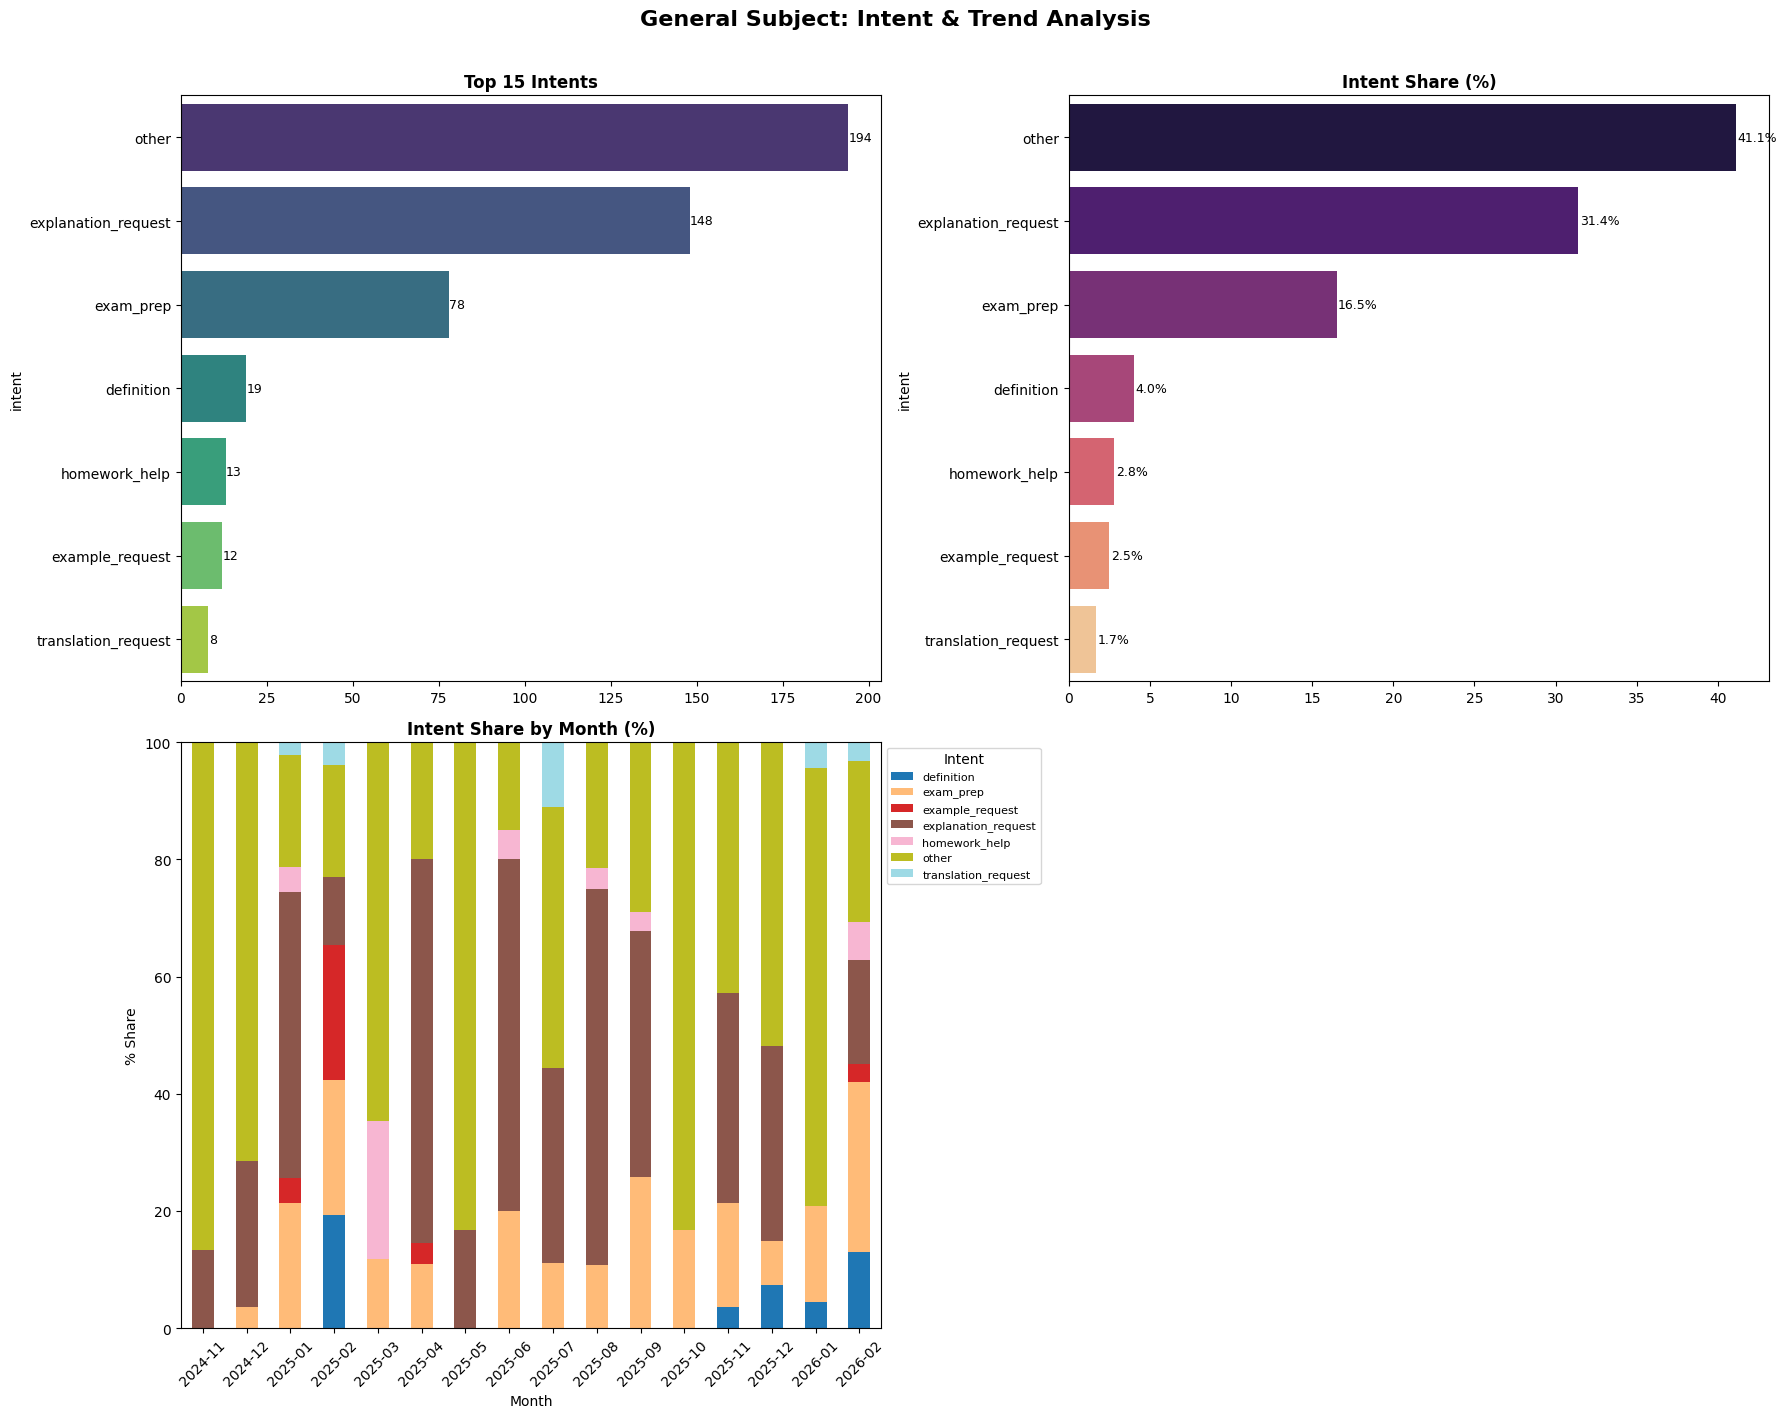

In [14]:

# 1. Load and Filter
general_df = pd.read_csv("classified_messages.csv")
general_df = general_df[general_df["subject"].str.lower() == "general"].copy()

# 2. Chronological Sort (Fixes ax3 jumping months)
if "month" in general_df.columns:
    general_df['month_dt'] = pd.to_datetime(general_df['month'], errors='coerce')
    general_df = general_df.sort_values('month_dt')

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("General Subject: Intent & Trend Analysis", fontsize=16, fontweight="bold", y=1.01)

# ax1: Intent Distribution (Replaces 'topic')
ax1 = axes[0, 0]
top_intents = general_df["intent"].value_counts().head(15)
sns.barplot(x=top_intents.values, y=top_intents.index, ax=ax1, palette="viridis")
ax1.set_title("Top 15 Intents", fontweight="bold")
for i, v in enumerate(top_intents.values):
    ax1.text(v + 0.1, i, str(v), va="center", fontsize=9)

# ax2: Intent Breakdown (Replacing category which wasn't in your .head())
ax2 = axes[0, 1]
# If freq_table isn't defined, we'll use a standard count
intent_counts = general_df["intent"].value_counts(normalize=True).mul(100).round(1)
sns.barplot(x=intent_counts.values, y=intent_counts.index, ax=ax2, palette="magma")
ax2.set_title("Intent Share (%)", fontweight="bold")
for i, v in enumerate(intent_counts.values):
    ax2.text(v + 0.1, i, f'{v}%', va="center", fontsize=9)

# ax3: Intent Share by Month (Replacing category)
ax3 = axes[1, 0]
intent_month = (
    general_df.groupby(["month", "intent"])
    .size()
    .unstack(fill_value=0)
)
# Ensure it stays in the sorted order from our datetime conversion
intent_month = intent_month.reindex(general_df["month"].unique())

intent_month_pct = intent_month.div(intent_month.sum(axis=1), axis=0) * 100
intent_month_pct.plot(kind="bar", stacked=True, ax=ax3, colormap="tab20")

ax3.set_title("Intent Share by Month (%)", fontweight="bold")
ax3.set_xlabel("Month")
ax3.set_ylabel("% Share")
ax3.tick_params(axis="x", rotation=45)
ax3.legend(loc="upper left", fontsize=8, title="Intent", bbox_to_anchor=(1, 1))

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [15]:
general_df = general_df[general_df["intent"] == "other"].copy().reset_index(drop=True)
print(f"Running topic analysis on {len(general_df):,} 'general' messages")

all_topics = []
questions_gen = general_df["question"].tolist()

for start in range(0, len(questions_gen), BATCH_SIZE):
    batch = questions_gen[start : start + BATCH_SIZE]
    topics = topic_batch(batch)
    all_topics.extend(topics)
    print(f"  {min(start + BATCH_SIZE, len(questions_gen)):,} / {len(questions_gen):,}", end="\r")
    time.sleep(15)

topics_df = pd.DataFrame(all_topics)
general_df = pd.concat([general_df, topics_df], axis=1)

Running topic analysis on 194 'general' messages


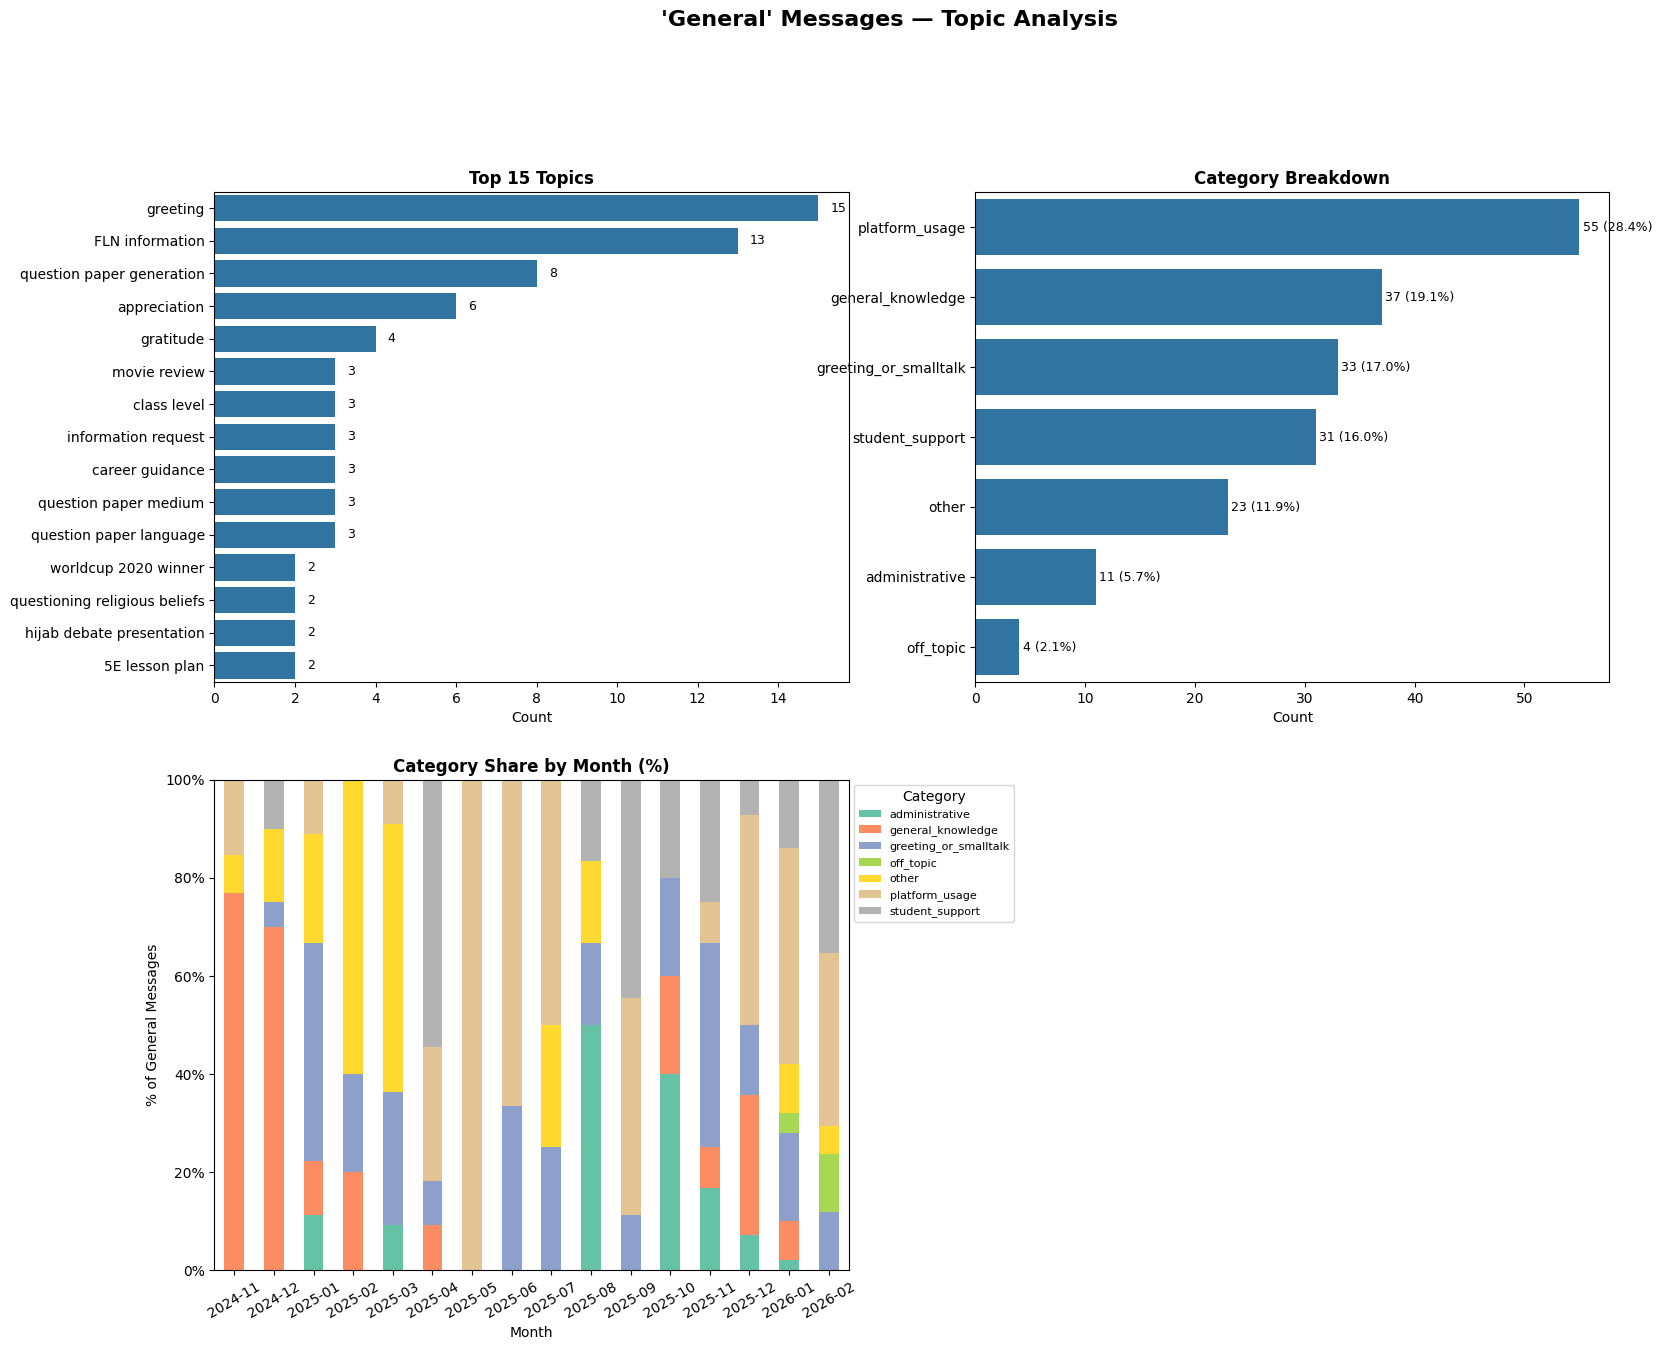

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("'General' Messages — Topic Analysis", fontsize=16, fontweight="bold", y=1.01)

ax1 = axes[0, 0]
top_topics = general_df["topic"].value_counts().head(15)
sns.barplot(x=top_topics.values, y=top_topics.index, ax=ax1)
ax1.set_title("Top 15 Topics", fontweight="bold")
ax1.set_xlabel("Count")
ax1.set_ylabel("")
for i, v in enumerate(top_topics.values):
    ax1.text(v + 0.3, i, str(v), va="center", fontsize=9)

ax2 = axes[0, 1]
cat_data = freq_table(general_df["category"], "category")
sns.barplot(x=cat_data["count"], y=cat_data["category"], ax=ax2)
ax2.set_title("Category Breakdown", fontweight="bold")
ax2.set_xlabel("Count")
ax2.set_ylabel("")
for i, row in cat_data.iterrows():
    ax2.text(row["count"] + 0.3, i, f'{row["count"]} ({row["pct"]}%)', va="center", fontsize=9)

ax3 = axes[1, 0]
cat_month = (
    general_df.groupby(["month", "category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
cat_month_pct = cat_month.div(cat_month.sum(axis=1), axis=0) * 100
cat_month_pct.plot(kind="bar", stacked=True, ax=ax3, colormap="Set2")
ax3.set_title("Category Share by Month (%)", fontweight="bold")
ax3.set_xlabel("Month")
ax3.set_ylabel("% of General Messages")
ax3.tick_params(axis="x", rotation=30)
ax3.legend(loc="upper left", fontsize=8, title="Category", bbox_to_anchor=(1, 1))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1, 1].axis('off')
plt.show()

number of power users sending >1.5 messages, what kind of messages are they sending
follow-up messages.

In [ ]:
def compare_dist(column_name):
    overall = df[column_name].value_counts(normalize=True)
    follow_up = follow_up_df[column_name].value_counts(normalize=True)
    comparison = pd.concat([overall, follow_up], axis=1, keys=['Overall %', 'Follow-up %'])
    return comparison.fillna(0) 

def plot_dist(column, ax):
    overall = df[column].value_counts(normalize=True).sort_index()
    follow_up = follow_up_df[column].value_counts(normalize=True).sort_index()
    comparison = pd.DataFrame({'Overall %': overall, 'Follow-up %': follow_up}).fillna(0)
    comparison.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'])
    ax.set_title(f'Distribution Comparison: {column.capitalize()}')
    ax.set_ylabel('Proportion')
    ax.set_xlabel(column.capitalize())

def plot_normalized_dist(column, ax):
    pivot = df_comparison.groupby(['academic_year', column]).size().unstack(level=0, fill_value=0)
    dist_pct = pivot.div(pivot.sum(axis=0), axis=1) 
    dist_pct.plot(kind='bar', ax=ax, color=['#95a5a6', '#2980b9'], width=0.8)
    ax.set_title(f'{column.capitalize()} Distribution Change')
    ax.set_ylabel('Proportion of Total Year Messages')
    ax.legend(title="Academic Year")
    ax.set_xlabel(None)

def get_academic_year(dt):
    if (dt.month > 7) or (dt.month == 7 and dt.day >= 16): #First LBA circular sent on 16th July 2025
        return f"{dt.year}-{str(dt.year + 1)[2:]}"
    else:
        return f"{dt.year - 1}-{str(dt.year)[2:]}"

In [4]:
df = pd.read_csv("classified_messages.csv")
counts = df.groupby('doc_id').size()
num_groups = (counts > 1).sum()
print(num_groups)

299


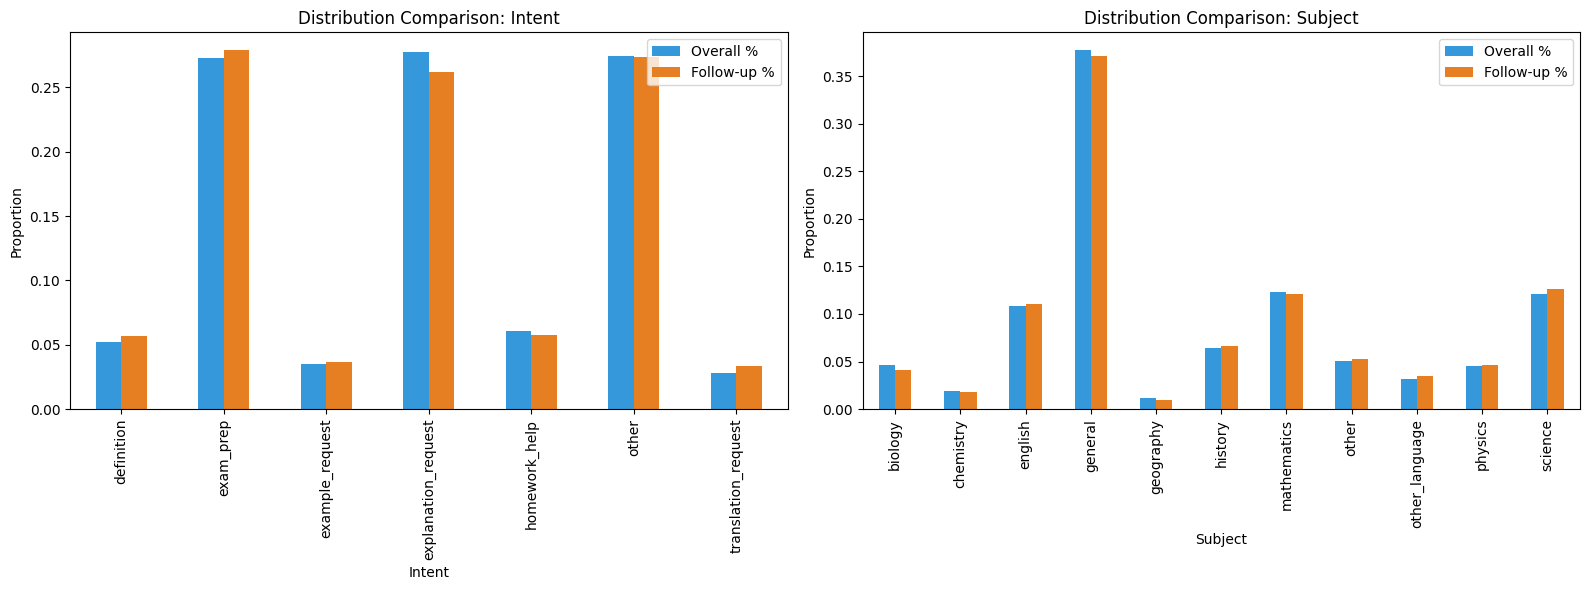

In [ ]:
follow_up_df = df[df.groupby('doc_id')['doc_id'].transform('count') > 1]

is_follow_up = df.groupby('doc_id')['doc_id'].transform('count') > 1
follow_up_df = df[is_follow_up]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_dist('intent', ax1)
plot_dist('subject', ax2)
plt.tight_layout()
plt.show()

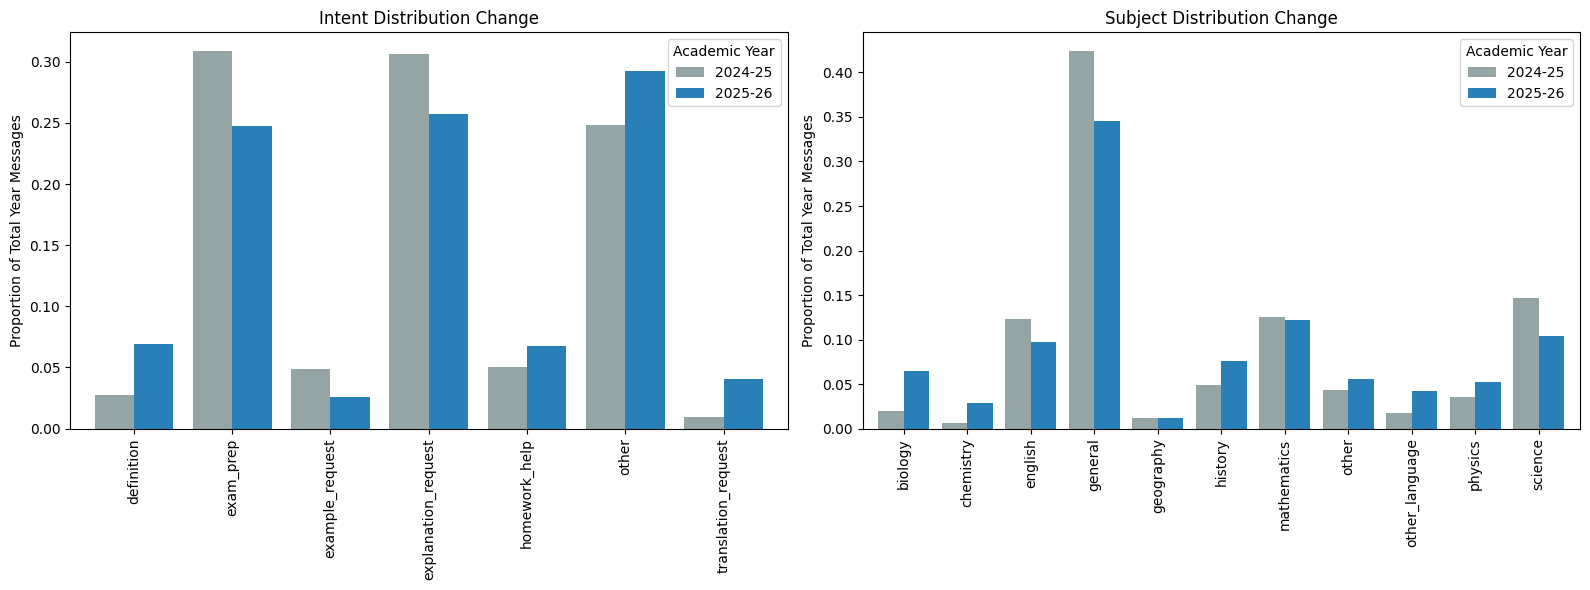

In [15]:
df['msg_date'] = pd.to_datetime(df['msg_date'], utc=True, format='ISO8601')
df['academic_year'] = df['msg_date'].apply(get_academic_year)


target_years = ['2024-25', '2025-26']
df_comparison = df[df['academic_year'].isin(target_years)]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_normalized_dist('intent', ax1)
plot_normalized_dist('subject', ax2)

plt.tight_layout()
plt.show()
